In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("saidaminsaidaxmadov/chocolate-sales")

print("Path to dataset files:", path)

100%|██████████| 457k/457k [00:00<00:00, 69.5MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/saidaminsaidaxmadov/chocolate-sales/versions/2


In [3]:
import pandas as pd
import os

dataset_path = '/root/.cache/kagglehub/datasets/saidaminsaidaxmadov/chocolate-sales/versions/2'
files = os.listdir(dataset_path)

# Automatically pick the first CSV file found in that folder
csv_file = [f for f in files if f.endswith('.csv')][0]
full_path = os.path.join(dataset_path, csv_file)

print(f"Loading file: {csv_file}\n")

# Load the dataset into a Pandas DataFrame
df = pd.read_csv(full_path)

# Display the first 5 rows of data beautifully
df.head()

Loading file: Chocolate Sales (2).csv



,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,"$5,320.00",180
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,"$7,896.00",94
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,"$4,501.00",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,"$12,726.00",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,"$13,685.00",184


In [6]:
df.head()

df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Sales Person   3282 non-null   object
 1   Country        3282 non-null   object
 2   Product        3282 non-null   object
 3   Date           3282 non-null   object
 4   Amount         3282 non-null   object
 5   Boxes Shipped  3282 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 154.0+ KB


,0
Sales Person,0
Country,0
Product,0
Date,0
Amount,0
Boxes Shipped,0


In [8]:
df['Date'] = pd.to_datetime(
    df['Date'],
    format='%d/%m/%Y'
)

In [9]:
#group sales by month
monthly_sales = df.groupby(
    pd.Grouper(key='Date', freq='M')
)['Amount'].sum()
print(monthly_sales)

Date
2022-01-31    $7,154.00$9,982.00$9,310.00$3,745.00$3,528.00$...
2022-02-28    $1,540.00$3,374.00$10,171.00$9,989.00$2,464.00...
2022-03-31    $5,229.00$15,008.00$12,313.00$5,446.00$1,043.0...
2022-04-30    $49.00$7,287.00$1,064.00$10,976.00$4,193.00$5,...
2022-05-31    $3,178.00$2,905.00$2,751.00$8,393.00$2,520.00$...
2022-06-30    $448.00$938.00$4,438.00$784.00$2,926.00$210.00...
2022-07-31    $5,075.00$7,728.00$7,756.00$2,835.00$2,443.00$...
2022-08-31    $7,896.00$63.00$3,605.00$3,640.00$7,882.00$6,7...
2022-09-30                                                    0
2022-10-31                                                    0
2022-11-30                                                    0
2022-12-31                                                    0
2023-01-31    $7,990.91$9,957.66$9,865.05$3,967.85$3,563.09$...
2023-02-28    $1,775.18$3,782.83$10,338.27$10,265.97$2,525.9...
2023-03-31    $5,747.66$15,653.44$13,018.00$5,857.90$1,177.6...
2023-04-30    $51.29$7,374.26$1,062

/tmp/ipykernel_5703/3669777110.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(key='Date', freq='M')


In [13]:
df.dtypes

,0
Sales Person,object
Country,object
Product,object
Date,datetime64[ns]
Amount,object
Boxes Shipped,int64


In [14]:
type(monthly_sales)

pandas.core.series.Series

In [15]:
monthly_sales.head()

,Amount
Date,
2022-01-31,"$7,154.00$9,982.00$9,310.00$3,745.00$3,528.00$..."
2022-02-28,"$1,540.00$3,374.00$10,171.00$9,989.00$2,464.00..."
2022-03-31,"$5,229.00$15,008.00$12,313.00$5,446.00$1,043.0..."
2022-04-30,"$49.00$7,287.00$1,064.00$10,976.00$4,193.00$5,..."
2022-05-31,"$3,178.00$2,905.00$2,751.00$8,393.00$2,520.00$..."


In [16]:
print(df['Amount'].head())

0     $5,320.00
1     $7,896.00
2     $4,501.00
3    $12,726.00
4    $13,685.00
Name: Amount, dtype: object


In [17]:
df['Amount'] = (
    df['Amount']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)
print(df.dtypes)

Sales Person             object
Country                  object
Product                  object
Date             datetime64[ns]
Amount                  float64
Boxes Shipped             int64
dtype: object


In [18]:
monthly_sales = df.groupby(
    pd.Grouper(key='Date', freq='ME')
)['Amount'].sum()

print(monthly_sales.head())

Date
2022-01-31    896105.0
2022-02-28    699377.0
2022-03-31    749483.0
2022-04-30    674051.0
2022-05-31    752892.0
Freq: ME, Name: Amount, dtype: float64


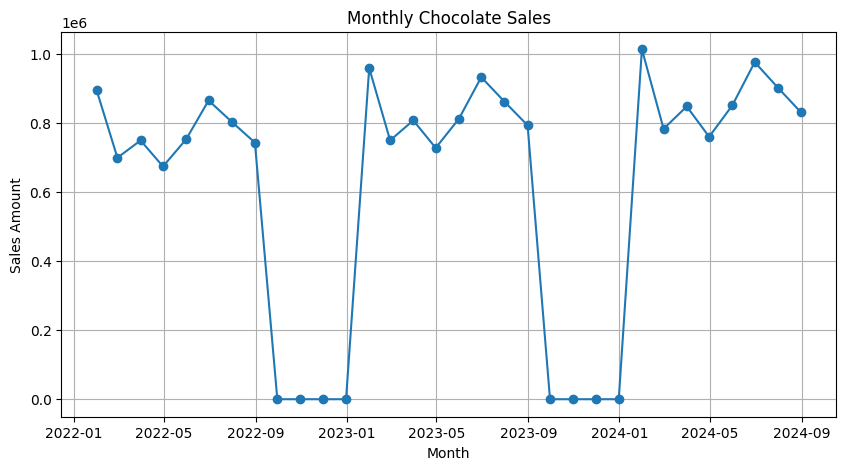

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index,
         monthly_sales.values,
         marker='o')

plt.title('Monthly Chocolate Sales')
plt.xlabel('Month')
plt.ylabel('Sales Amount')
plt.grid(True)

plt.show()

In [20]:
forecast_df = monthly_sales.reset_index()

forecast_df.columns = ['Date', 'Sales']

print(forecast_df.head())

        Date     Sales
0 2022-01-31  896105.0
1 2022-02-28  699377.0
2 2022-03-31  749483.0
3 2022-04-30  674051.0
4 2022-05-31  752892.0


In [21]:
forecast_df['Month_Number'] = range(1, len(forecast_df)+1)

print(forecast_df.head())

        Date     Sales  Month_Number
0 2022-01-31  896105.0             1
1 2022-02-28  699377.0             2
2 2022-03-31  749483.0             3
3 2022-04-30  674051.0             4
4 2022-05-31  752892.0             5


In [22]:
from sklearn.model_selection import train_test_split

X = forecast_df[['Month_Number']]
y = forecast_df['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

In [23]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [24]:
y_pred = model.predict(X_test)

print(y_pred)

[380844.6266     367553.82932308 354263.03204615 340972.23476923
 327681.43749231 314390.64021538 301099.84293846]


In [25]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 509163.0623736264


In [27]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: -58.01356584624494


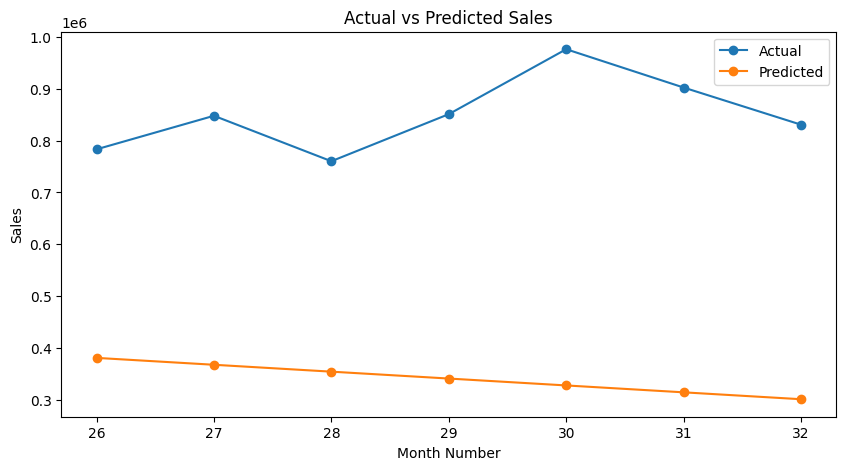

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    X_test,
    y_test,
    marker='o',
    label='Actual'
)

plt.plot(
    X_test,
    y_pred,
    marker='o',
    label='Predicted'
)

plt.title('Actual vs Predicted Sales')
plt.xlabel('Month Number')
plt.ylabel('Sales')

plt.legend()

plt.show()

In [29]:
future_months = pd.DataFrame({
    'Month_Number': [
        len(forecast_df)+1,
        len(forecast_df)+2,
        len(forecast_df)+3
    ]
})

future_predictions = model.predict(future_months)

print(future_predictions)

[287809.04566154 274518.24838462 261227.45110769]


In [30]:
print(len(forecast_df))

32


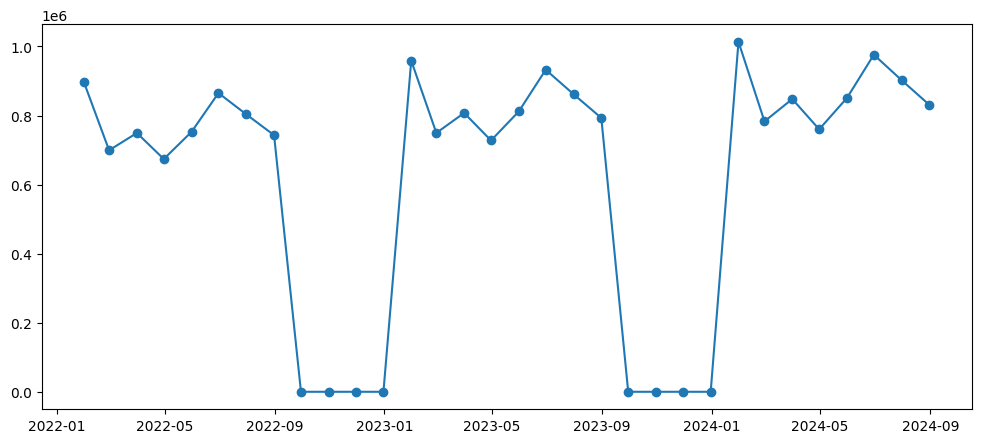

In [31]:
plt.figure(figsize=(12,5))
plt.plot(forecast_df['Date'],
         forecast_df['Sales'],
         marker='o')
plt.show()

In [32]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [33]:
model = ExponentialSmoothing(
    monthly_sales,
    trend='add',
    seasonal='add',
    seasonal_periods=12
)

fit_model = model.fit()

In [34]:
forecast = fit_model.forecast(3)

print(forecast)

2024-09-30    65917.816466
2024-10-31    68946.368519
2024-11-30    67470.891757
Freq: ME, dtype: float64


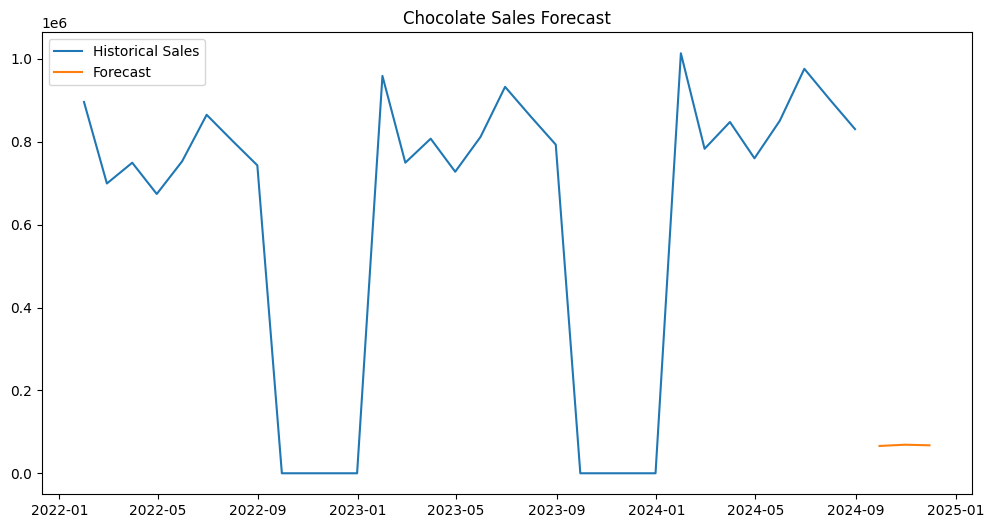

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    label='Historical Sales'
)

plt.plot(
    forecast.index,
    forecast.values,
    label='Forecast'
)

plt.legend()
plt.title('Chocolate Sales Forecast')

plt.show()

In [37]:
monthly_sales[monthly_sales == 0]

,Amount
Date,
2022-09-30,0.0
2022-10-31,0.0
2022-11-30,0.0
2022-12-31,0.0
2023-09-30,0.0
2023-10-31,0.0
2023-11-30,0.0
2023-12-31,0.0


In [38]:
print(df['Amount'].head())
print(df['Amount'].max())
print(df['Amount'].min())

0     5320.0
1     7896.0
2     4501.0
3    12726.0
4    13685.0
Name: Amount, dtype: float64
26170.95
7.0


In [39]:
print(monthly_sales.describe())

count    3.200000e+01
mean     6.184866e+05
std      3.708179e+05
min      0.000000e+00
25%      5.055382e+05
50%      7.716175e+05
75%      8.536443e+05
max      1.013622e+06
Name: Amount, dtype: float64


In [40]:
df[df['Amount'] == 0]

,Sales Person,Country,Product,Date,Amount,Boxes Shipped


In [41]:
df[df['Date'].dt.month.isin([9,10,11,12])]

,Sales Person,Country,Product,Date,Amount,Boxes Shipped


In [42]:
monthly_sales = monthly_sales[monthly_sales > 0]

In [43]:
print(monthly_sales)

Date
2022-01-31     896105.00
2022-02-28     699377.00
2022-03-31     749483.00
2022-04-30     674051.00
2022-05-31     752892.00
2022-06-30     865144.00
2022-07-31     803425.00
2022-08-31     743148.00
2023-01-31     958985.77
2023-02-28     749617.46
2023-03-31     807494.33
2023-04-30     727743.72
2023-05-31     811951.78
2023-06-30     932625.17
2023-07-31     861856.66
2023-08-31     793103.07
2024-01-31    1013621.82
2024-02-29     783102.44
2024-03-31     847791.96
2024-04-30     760132.50
2024-05-31     850906.79
2024-06-30     976162.77
2024-07-31     902250.63
2024-08-31     830599.99
Name: Amount, dtype: float64


In [44]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model = ExponentialSmoothing(
    monthly_sales,
    trend='add',
    seasonal='add',
    seasonal_periods=8
)

fit_model = model.fit()

forecast = fit_model.forecast(3)

print(forecast)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


24    1.048342e+06
25    8.293111e+05
26    8.876091e+05
dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
